# FCN (Segmentazione semantica)  

**Obiettivo:** usare un modello FCN pre-addestrato per etichettare ogni pixel con una classe.


In [4]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
from imageio.v2 import imread



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Carichiamo FCN-ResNet50 pre-addestrato su COCO-stuff (o simile)
try:
    fcn = models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.DEFAULT)
    fcn = fcn.to(device)
    fcn.eval()
    print("FCN-ResNet50 caricato.")
except Exception as e:
    print("Errore nel caricare FCN pre-addestrato:", e)
    fcn = None

# Trasformazioni per FCN (come suggerite dai weights)
if fcn is not None:
    preprocess = models.segmentation.FCN_ResNet50_Weights.DEFAULT.transforms()
else:
    preprocess = transforms.Compose([
        transforms.Resize((520, 520)),
        transforms.ToTensor()
    ])

Device: cpu
FCN-ResNet50 caricato.


## 2) Funzione per visualizzare la segmentazione

In [6]:
def decode_segmap(mask):
    """Converte una mappa di classi [H,W] in un'immagine RGB colorata.
    Qui usiamo una colormap semplice, non identica a COCO, ma sufficiente per uso didattico.
    """
    # Creiamo una tavolozza casuale per 21 classi (tipo PASCAL-like), per esempio
    n_classes = int(mask.max().item()) + 1
    colors = np.random.RandomState(0).randint(0, 255, size=(n_classes, 3), dtype=np.uint8)

    h, w = mask.shape
    seg_img = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(n_classes):
        seg_img[mask == c] = colors[c]
    return seg_img

def show_segmentation(pil_img, seg_mask):
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(pil_img)
    axes[0].set_title("Immagine originale")
    axes[0].axis("off")

    seg_img = decode_segmap(seg_mask)
    axes[1].imshow(seg_img)
    axes[1].set_title("Mappa di segmentazione")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

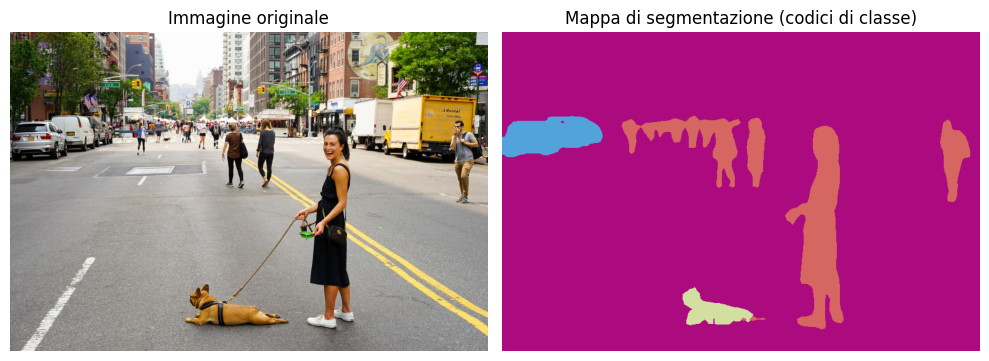

In [ ]:
path_img = "../data/img/road.jpg"
img = imread(path_img)              # numpy array (H, W, C), uint8

# Converti in float e normalizza in [0, 1]
img = img.astype(np.float32) / 255.0

# Da (H, W, C) -> (C, H, W)
img_tensor = torch.from_numpy(img).permute(2, 0, 1)

# Preprocess
input_tensor = preprocess(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    out = fcn(input_tensor)["out"]  # [1, num_classes, H, W]

# Argmax sulle classi
mask = out.argmax(dim=1).squeeze(0).cpu().numpy()

show_segmentation(img, mask)